In [1]:

import pandas as pd

df = pd.read_csv("ford_car_dataset - ford_car_dataset.csv")

# First 10 rows
print(df.head(10))

# Last 5 rows
print(df.tail(5))

# Shape
print("Shape:", df.shape)

# Data Types
print(df.dtypes)

    model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0  Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1   Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2   Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3  Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4  Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
5  Fiesta  2015  10500       Manual    35432   Petrol  145  47.9         1.6
6    Puma  2019  22500       Manual     2029   Petrol  145  50.4         1.0
7  Fiesta  2017   9000       Manual    13054   Petrol  145  54.3         1.2
8    Kuga  2019  25500    Automatic     6894   Diesel  145  42.2         2.0
9   Focus  2018  10000       Manual    48141   Petrol  145  61.4         1.0
       model  year  price transmission  mileage fuelType  tax   mpg  \
17961  B-MAX  2017   8999       Manual    16700   Petrol  150  47.1   
17962  B-MA

In [2]:
# Missing values
print(df.isnull().sum())

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("New Shape:", df.shape)

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64
Duplicate rows: 154
New Shape: (17812, 9)


In [3]:
print(df.describe())

print("Price")
print("Mean :", df["price"].mean())
print("Median :", df["price"].median())
print("Minimum :", df["price"].min())
print("Maximum :", df["price"].max())

print("Mileage")
print("Mean :", df["mileage"].mean())
print("Median :", df["mileage"].median())
print("Minimum :", df["mileage"].min())
print("Maximum :", df["mileage"].max())

print("Year")
print("Mean :", df["year"].mean())
print("Median :", df["year"].median())
print("Minimum :", df["year"].min())
print("Maximum :", df["year"].max())

               year         price        mileage           tax           mpg  \
count  17812.000000  17812.000000   17812.000000  17812.000000  17812.000000   
mean    2016.862396  12269.556310   23381.146362    113.315012     57.908696   
std        2.052039   4736.285417   19419.011045     62.034603     10.132696   
min     1996.000000    495.000000       1.000000      0.000000     20.800000   
25%     2016.000000   8999.000000   10000.000000     30.000000     52.300000   
50%     2017.000000  11288.000000   18277.000000    145.000000     58.900000   
75%     2018.000000  15295.000000   31098.500000    145.000000     65.700000   
max     2060.000000  54995.000000  177644.000000    580.000000    201.800000   

         engineSize  
count  17812.000000  
mean       1.350623  
std        0.432581  
min        0.000000  
25%        1.000000  
50%        1.200000  
75%        1.500000  
max        5.000000  
Price
Mean : 12269.556310352571
Median : 11288.0
Minimum : 495
Maximum : 54995
Mi

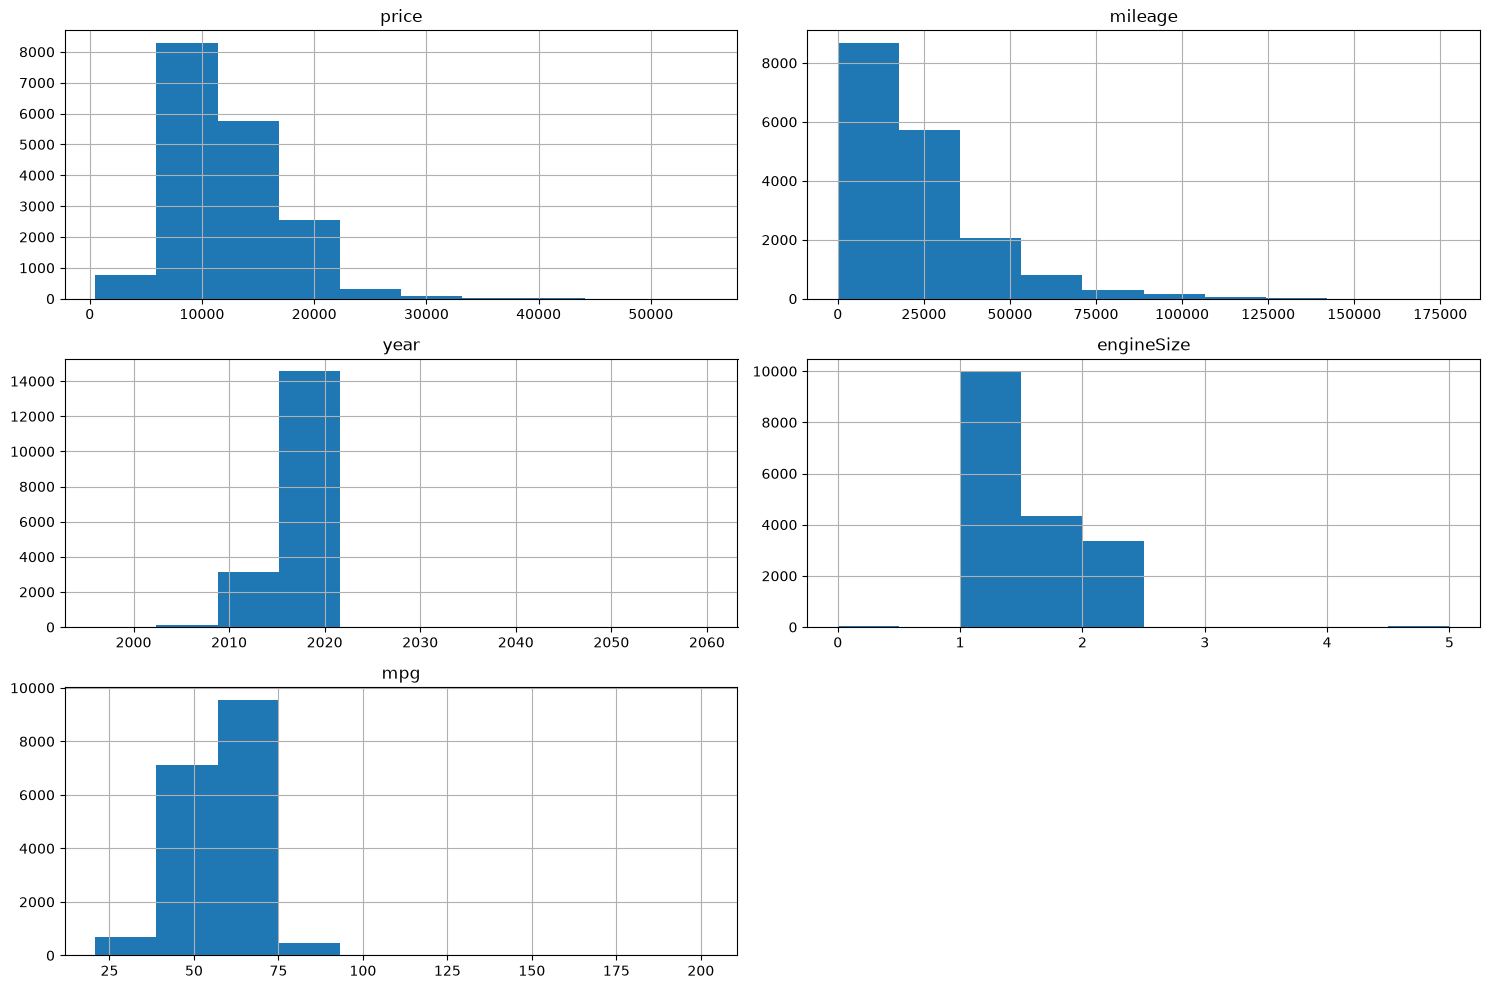

In [4]:
import matplotlib.pyplot as plt

num_cols = ["price","mileage","year","engineSize","mpg"]

df[num_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()
# Price is right-skewed.
# Mileage is positively skewed.
# Most cars belong to recent years (2016-2019).
# Engine size is concentrated around 1.0–2.0L.
# MPG values mainly lie between 40 and 70.

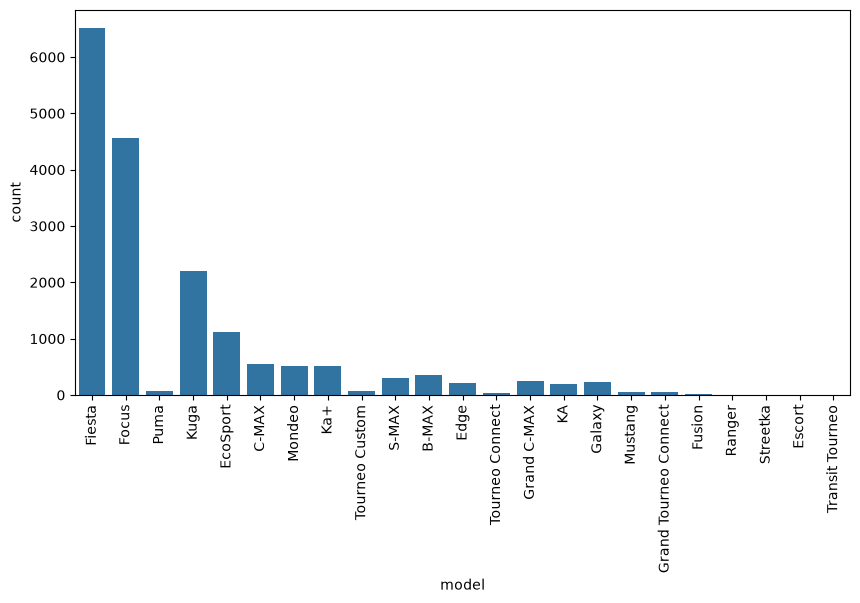

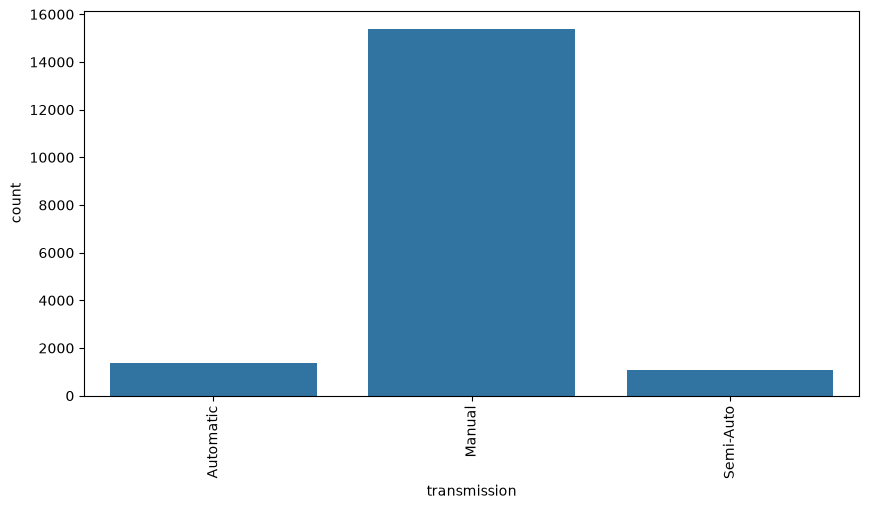

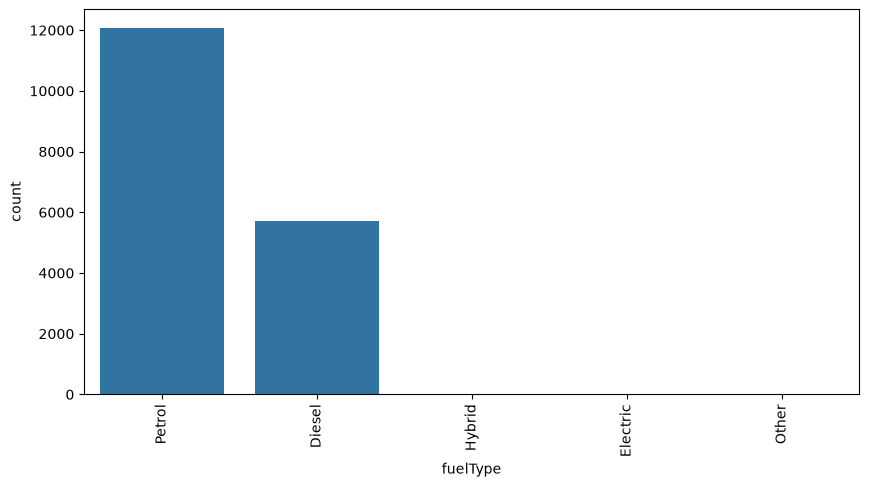

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_cols = ["model","transmission","fuelType"]

for col in cat_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=90)
    plt.show()
    # Petrol cars are the most common.
# Manual transmission dominates.
# Fiesta and Focus are among the most frequent models.

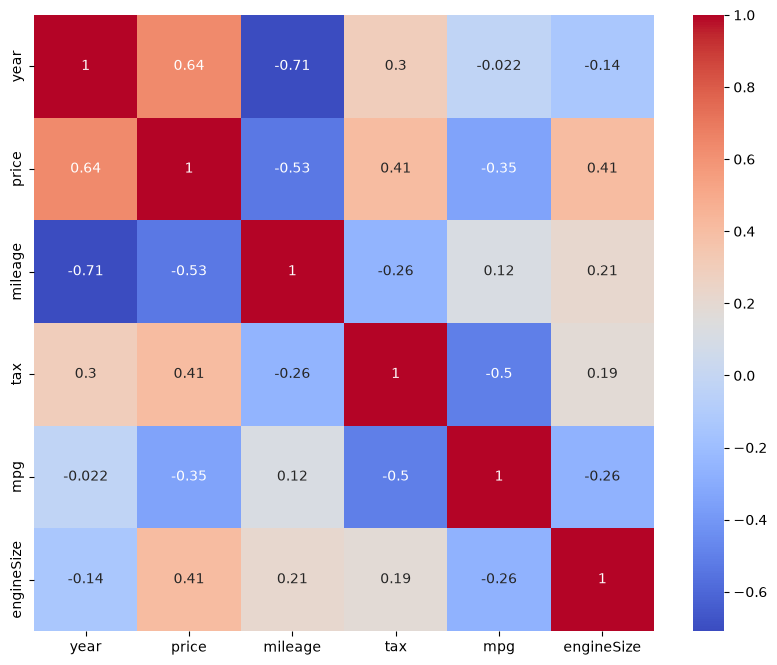

In [6]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()
# Price is positively correlated with Year.
# Price is negatively correlated with Mileage.
# Engine Size has a moderate positive correlation with Price.

Independant Features:-
model
year
transmission
mileage
fuelType
tax
mpg
engineSize

Dependant Features:-
Price

Reason:-
Price is the value to be predicted.
All remaining variables help explain or predict the selling price.


In [7]:
import pandas as pd

# Display categorical columns before encoding
print("Before Encoding:\n")
print(df[["fuelType", "transmission"]].head())

# Apply One-Hot Encoding
encoded = pd.get_dummies(
    df,
    columns=["fuelType", "transmission", "model"],
    drop_first=True
)

# Display first 5 rows after encoding
print("\nAfter Encoding:\n")
print(encoded.head())

# ------------------ Observations ------------------
# 1. Before encoding, the columns 'fuelType', 'transmission',
#    and 'model' contain categorical (text) values.
#
# 2. After One-Hot Encoding, each unique category is converted
#    into a separate binary (0/1) column.
#
# 3. The parameter drop_first=True removes the first category
#    from each feature to avoid the Dummy Variable Trap
#    (multicollinearity).
#
# 4. The transformed dataset now contains only numerical values,
#    making it suitable for machine learning algorithms.
# ---------------------------------------------------

Before Encoding:

  fuelType transmission
0   Petrol    Automatic
1   Petrol       Manual
2   Petrol       Manual
3   Petrol       Manual
4   Petrol    Automatic

After Encoding:

   year  price  mileage  tax   mpg  engineSize  fuelType_Electric  \
0  2017  12000    15944  150  57.7         1.0              False   
1  2018  14000     9083  150  57.7         1.0              False   
2  2017  13000    12456  150  57.7         1.0              False   
3  2019  17500    10460  145  40.3         1.5              False   
4  2019  16500     1482  145  48.7         1.0              False   

   fuelType_Hybrid  fuelType_Other  fuelType_Petrol  ...  model_Kuga  \
0            False           False             True  ...       False   
1            False           False             True  ...       False   
2            False           False             True  ...       False   
3            False           False             True  ...       False   
4            False           False           

In [8]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [9]:
from sklearn.preprocessing import StandardScaler

X = encoded.drop("price", axis=1)

numeric_cols = ["year","mileage","tax","mpg","engineSize"]

scaler = StandardScaler()

X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print(X.head())

       year   mileage       tax       mpg  engineSize  fuelType_Electric  \
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561              False   
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561              False   
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561              False   
3  1.041726 -0.665405  0.510777 -1.737858    0.345325              False   
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561              False   

   fuelType_Hybrid  fuelType_Other  fuelType_Petrol  transmission_Manual  ...  \
0            False           False             True                False  ...   
1            False           False             True                 True  ...   
2            False           False             True                 True  ...   
3            False           False             True                 True  ...   
4            False           False             True                False  ...   

   model_Kuga  model_Mondeo  model_Mustang  model_Puma  

Original Shape: (17966, 9)

Missing Values:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Duplicate Rows: 154
Shape After Removing Duplicates: (17812, 9)


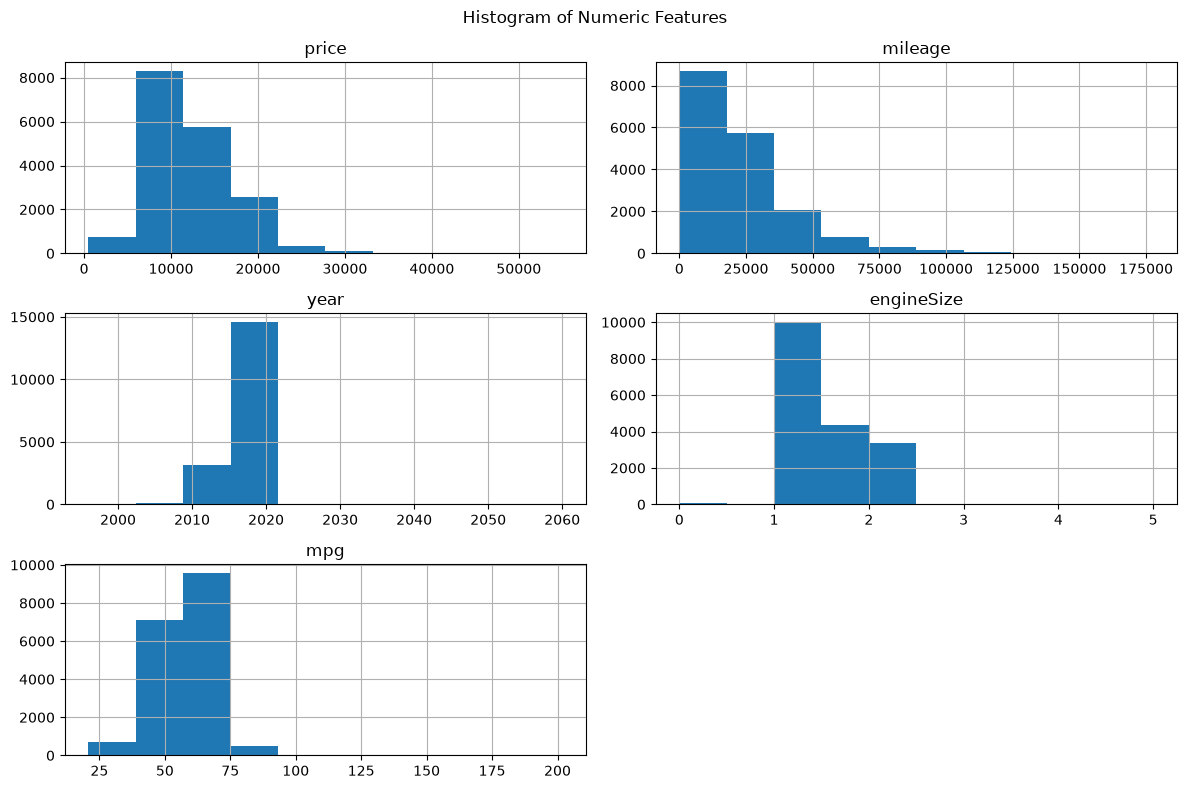

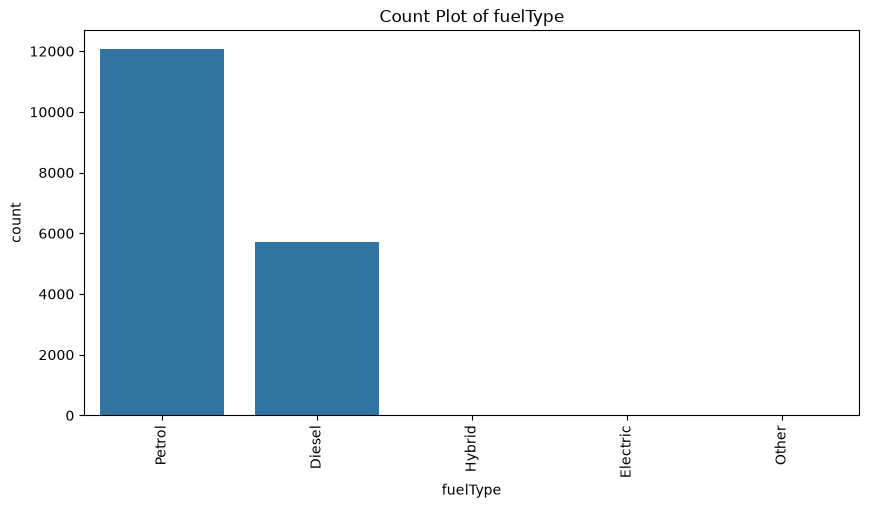

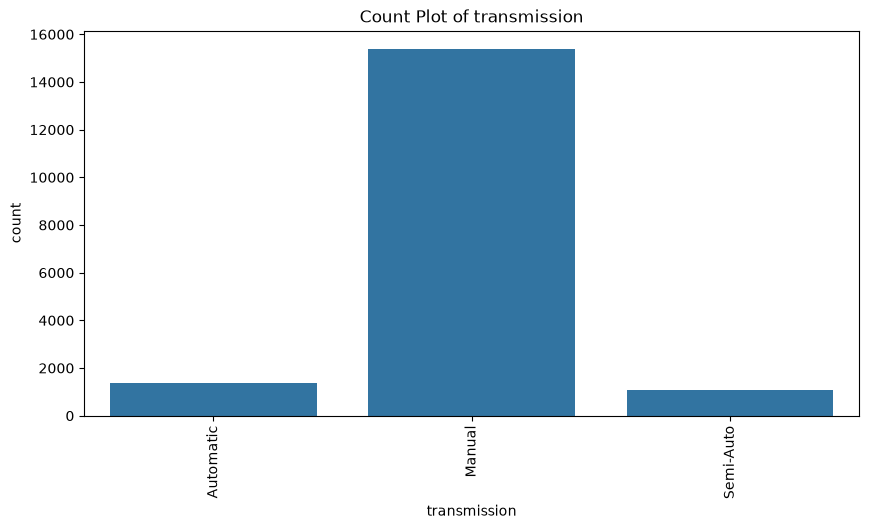

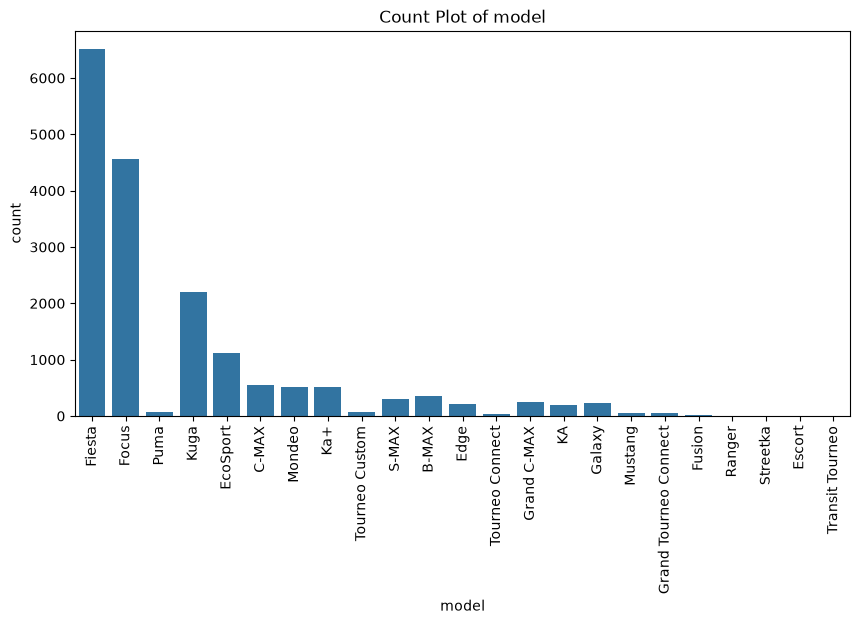

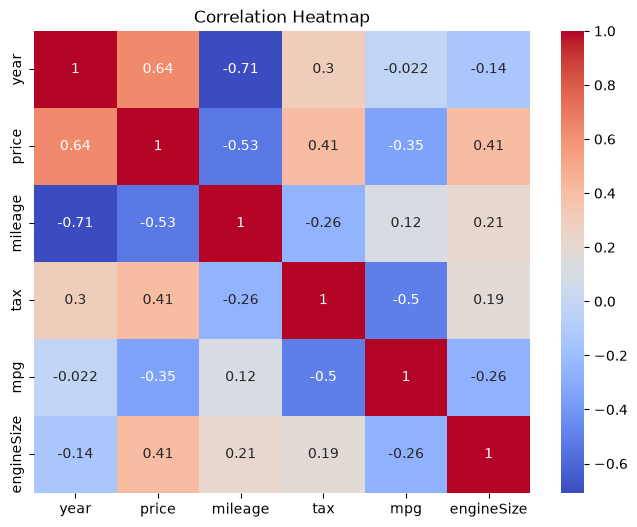


Input Features:
Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='str')

Target Feature:
price

Shape After Encoding: (17812, 33)

First 5 Rows of Preprocessed Data:
       year   mileage       tax       mpg  engineSize  model_C-MAX  \
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561        False   
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561        False   
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561        False   
3  1.041726 -0.665405  0.510777 -1.737858    0.345325        False   
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561        False   

   model_EcoSport  model_Edge  model_Escort  model_Fiesta  ...  \
0           False       False         False          True  ...   
1           False       False         False         False  ...   
2           False       False         False         False  ...   
3           False       False         False          True  ...   
4           False   

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# Step 1: Load Dataset
# --------------------------------------------------
df = pd.read_csv("ford_car_dataset - ford_car_dataset.csv")

print("Original Shape:", df.shape)

# --------------------------------------------------
# Step 2: Data Cleaning
# --------------------------------------------------

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicate rows
duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

# --------------------------------------------------
# Step 3: Exploratory Data Analysis (EDA)
# --------------------------------------------------

# Histograms
numeric_cols = ["price", "mileage", "year", "engineSize", "mpg"]

df[numeric_cols].hist(figsize=(12,8))
plt.suptitle("Histogram of Numeric Features")
plt.tight_layout()
plt.show()

# Count Plots
categorical_cols = ["fuelType", "transmission", "model"]

for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=90)
    plt.title(f"Count Plot of {col}")
    plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# --------------------------------------------------
# Step 4: Identify Input and Output Features
# --------------------------------------------------

X = df.drop("price", axis=1)
y = df["price"]

print("\nInput Features:")
print(X.columns)

print("\nTarget Feature:")
print(y.name)

# --------------------------------------------------
# Step 5: Encode Categorical Variables
# --------------------------------------------------

X = pd.get_dummies(
    X,
    columns=["model", "fuelType", "transmission"],
    drop_first=True
)

print("\nShape After Encoding:", X.shape)

# --------------------------------------------------
# Step 6: Scale Numeric Features
# --------------------------------------------------

scaler = StandardScaler()

numeric_features = ["year", "mileage", "tax", "mpg", "engineSize"]

X[numeric_features] = scaler.fit_transform(X[numeric_features])

print("\nFirst 5 Rows of Preprocessed Data:")
print(X.head())

print("\nPreprocessing Pipeline Completed Successfully.")